In [6]:
!pip install yfinance -q

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [7]:
pip install tenacity -q

In [8]:
from tenacity import retry, stop_after_attempt, wait_fixed

@retry(stop=stop_after_attempt(3), wait=wait_fixed(5))
def download_data_with_retries(ticker, start, end, auto_adjust):
    print(f"Attempting to download data for {ticker}...")
    data = yf.download(ticker, start=start, end=end, auto_adjust=auto_adjust)
    if data.empty:
        raise Exception("Downloaded data is empty, retrying...")
    return data

In [9]:
ticker = "SPY"
data = download_data_with_retries(ticker, start="2010-01-01", end="2026-01-01", auto_adjust=True)

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

print(f"Shape: {data.shape}")
display(data.head())

Attempting to download data for SPY...


[*********************100%***********************]  1 of 1 completed

Shape: (4024, 5)


Price,Close,High,Low,Open,Volume
Date,,,,,
2010-01-04,84.578484,84.623260,83.220213,83.862034,118944600
2010-01-05,84.802361,84.839678,84.220245,84.526232,111579900
2010-01-06,84.862083,85.071047,84.653120,84.720284,116074400
2010-01-07,85.220306,85.324788,84.466539,84.705356,131091100
2010-01-08,85.503899,85.541216,84.824766,84.996413,126402800


In [10]:
ticker = "SPY"
data = yf.download(ticker, start="2010-01-01", end="2026-01-01", auto_adjust=True)

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

print(f"Shape: {data.shape}")
data.head()

[*********************100%***********************]  1 of 1 completed

Shape: (4024, 5)


Price,Close,High,Low,Open,Volume
Date,,,,,
2010-01-04,84.578484,84.623260,83.220213,83.862034,118944600
2010-01-05,84.802361,84.839678,84.220245,84.526232,111579900
2010-01-06,84.862083,85.071047,84.653120,84.720284,116074400
2010-01-07,85.220306,85.324788,84.466539,84.705356,131091100
2010-01-08,85.503899,85.541216,84.824766,84.996413,126402800


In [11]:
data.info()
print("\nMissing values:\n", data.isna().sum())
print("\nSummary stats:\n", data.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4024 entries, 2010-01-04 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   4024 non-null   float64
 1   High    4024 non-null   float64
 2   Low     4024 non-null   float64
 3   Open    4024 non-null   float64
 4   Volume  4024 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 188.6 KB

Missing values:
 Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Summary stats:
 Price        Close         High          Low         Open        Volume
count  4024.000000  4024.000000  4024.000000  4024.000000  4.024000e+03
mean    267.381333   268.767389   265.767215   267.333626  1.093601e+08
std     155.196677   155.963036   154.291703   155.177997  6.796507e+07
min      76.950607    77.869197    76.144963    77.635787  2.027000e+07
25%     145.848522   146.342603   145.514667   145.947770  6.523638e+07
50%     227.204430 

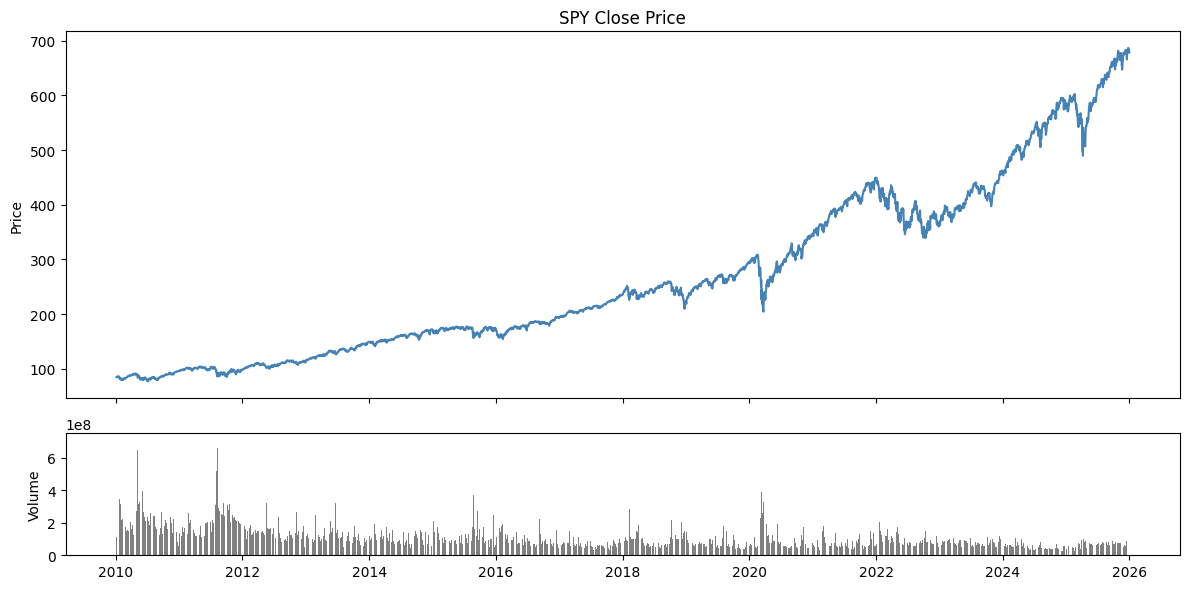

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

axes[0].plot(data.index, data['Close'], color='steelblue')
axes[0].set_title(f"{ticker} Close Price")
axes[0].set_ylabel("Price")

axes[1].bar(data.index, data['Volume'], color='gray', width=1)
axes[1].set_ylabel("Volume")

plt.tight_layout()
plt.show()

In [13]:
data.to_csv("spy_data.csv")

from google.colab import files
files.download("spy_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>